In [3]:
# Install the necessary libraries for chunked multidimensional arrays
!pip install xarray dask zarr numpy scipy

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!ls /content/drive/MyDrive

 best_climate_twin.pt
 climate_twin_cache.zarr
 climate_twin_climatology.zarr
 climate_twin_model_weights.pth
 climate_twin_outputs
 climate_twin_periodic_checkpoint_e10.pt
 climate_twin_periodic_checkpoint_e20.pt
 climate_twin_periodic_checkpoint_e30.pt
'Colab Notebooks'
'Imp documents '
 isro_climate_dataset


In [5]:
!ls /content/drive/MyDrive/isro_climate_dataset/Rainfall

1986.grd  1991.grd  1996.grd  2001.grd	2006.grd  2011.grd  2016.grd  2021.grd
1987.grd  1992.grd  1997.grd  2002.grd	2007.grd  2012.grd  2017.grd  2022.grd
1988.grd  1993.grd  1998.grd  2003.grd	2008.grd  2013.grd  2018.grd  2023.grd
1989.grd  1994.grd  1999.grd  2004.grd	2009.grd  2014.grd  2019.grd  2024.grd
1990.grd  1995.grd  2000.grd  2005.grd	2010.grd  2015.grd  2020.grd  2025.grd


In [19]:
import xarray as xr
import numpy as np
import glob
import os
import pandas as pd
import gc # Garbage collector for clearing RAM
import shutil # For removing directories

# --- 1. PATHS AND CONFIGURATION ---
RAIN_DIR = '/content/drive/MyDrive/isro_climate_dataset/Rainfall/'
MAXT_DIR = '/content/drive/MyDrive/isro_climate_dataset/Maxtemp/'
MINT_DIR = '/content/drive/MyDrive/isro_climate_dataset/Mintemp/'
# Modified to save directly to Google Drive
LOCAL_ZARR_PATH = '/content/drive/MyDrive/climate_twin_cache.zarr'
CLIMATOLOGY_ZARR_PATH = '/content/drive/MyDrive/climate_twin_climatology.zarr' # New path for climatology

# Grid Dimensions
RAIN_LAT_DIM, RAIN_LON_DIM = 135, 129
lat_rain = np.linspace(6.5, 38.5, RAIN_LAT_DIM)
lon_rain = np.linspace(66.5, 100.5, RAIN_LON_DIM)

TEMP_LAT_DIM, TEMP_LON_DIM = 31, 31
lat_temp = np.linspace(7.5, 37.5, TEMP_LAT_DIM)
lon_temp = np.linspace(67.5, 97.5, TEMP_LON_DIM)

rain_files = sorted(glob.glob(os.path.join(RAIN_DIR, '*.grd')))
# Corrected glob patterns for MaxTemp and MinTemp based on file naming and extension
maxt_files = sorted(glob.glob(os.path.join(MAXT_DIR, 'Maxtemp_MaxT_*.GRD')))
mint_files = sorted(glob.glob(os.path.join(MINT_DIR, '*.GRD')))

num_years = len(rain_files)
start_year = 1986

def load_and_regrid_single_year(year_idx):
    """Loads a single year, reshapes, and regrids temperature to match rainfall."""

    # Load raw binary arrays
    # -1 allows NumPy to automatically deduce 365 or 366 days (leap years)
    rain_arr = np.fromfile(rain_files[year_idx], dtype=np.float32).reshape(-1, RAIN_LAT_DIM, RAIN_LON_DIM)
    maxt_arr = np.fromfile(maxt_files[year_idx], dtype=np.float32).reshape(-1, TEMP_LAT_DIM, TEMP_LON_DIM)
    mint_arr = np.fromfile(mint_files[year_idx], dtype=np.float32).reshape(-1, TEMP_LAT_DIM, TEMP_LON_DIM)

    # The shape from reshape will be (days, lat, lon). `days_in_year` should be just the number of days.
    days_in_year = rain_arr.shape[0]
    current_year = start_year + year_idx
    time_index = pd.date_range(start=f'{current_year}-01-01', periods=days_in_year, freq='D')

    # Wrap in xarray
    da_rain = xr.DataArray(rain_arr, coords=[time_index, lat_rain, lon_rain], dims=['time', 'lat', 'lon'], name='rainfall')
    da_maxt = xr.DataArray(maxt_arr, coords=[time_index, lat_temp, lon_temp], dims=['time', 'lat', 'lon'], name='max_temp')
    da_mint = xr.DataArray(mint_arr, coords=[time_index, lat_temp, lon_temp], dims=['time', 'lat', 'lon'], name='min_temp')

    # Regrid temperatures to match rainfall 0.25 deg grid
    # Changed method from 'bilinear' to 'linear' for multidimensional interpolation in xarray
    da_maxt_regridded = da_maxt.interp(lat=lat_rain, lon=lon_rain, method='linear')
    da_mint_regridded = da_mint.interp(lat=lat_rain, lon=lon_rain, method='linear')

    ds = xr.merge([da_rain, da_maxt_regridded, da_mint_regridded])

    # Apply log transform to rainfall immediately
    ds['rainfall'] = np.log1p(ds['rainfall'].clip(min=0))

    return ds, days_in_year

# =========================================================
# PASS 1: INCREMENTAL CLIMATOLOGY (Low RAM) With Batch Processing
# =========================================================
print("Starting Pass 1: Calculating 40-year statistics...")

# Initialize accumulators
sum_ds = None
sum_sq_ds = None
total_days = 0

BATCH_YEARS = 6 # Process 6 years at once, as requested

for batch_start in range(0, num_years, BATCH_YEARS):
    batch_end = min(batch_start + BATCH_YEARS, num_years)

    print(f"  Calculating stats for Years {start_year + batch_start} - {start_year + batch_end - 1}...")

    batch_datasets_for_concat = []
    current_batch_days = 0

    for i in range(batch_start, batch_end):
        ds_year, days = load_and_regrid_single_year(i)
        batch_datasets_for_concat.append(ds_year)
        current_batch_days += days

    ds_batch = xr.concat(batch_datasets_for_concat, dim="time")

    if sum_ds is None:
        sum_ds = ds_batch.sum(dim='time')
        sum_sq_ds = (ds_batch**2).sum(dim='time')
    else:
        sum_ds += ds_batch.sum(dim='time')
        sum_sq_ds += (ds_batch**2).sum(dim='time')

    total_days += current_batch_days

    # CLEAR RAM
    del batch_datasets_for_concat, ds_batch
    gc.collect()

# Finalize 40-year Mean and Standard Deviation
climatology_mean = sum_ds / total_days
climatology_variance = (sum_sq_ds / total_days) - (climatology_mean**2)
climatology_std = np.sqrt(climatology_variance.clip(min=0))

print("Pass 1 Complete! Climatology established.")

# Safely remove existing climatology directory before saving
if os.path.exists(CLIMATOLOGY_ZARR_PATH):
    print(f"Removing existing climatology Zarr at {CLIMATOLOGY_ZARR_PATH}")
    shutil.rmtree(CLIMATOLOGY_ZARR_PATH)

# Save climatology to a zarr file for later use in evaluation
# The evaluate_test_set function expects 'mean' and 'std' to be Zarr groups
# which themselves contain the DataArrays for 'rainfall', 'max_temp', 'min_temp'
# So, we save the climatology_mean and climatology_std Datasets to sub-groups.
climatology_mean.to_zarr(CLIMATOLOGY_ZARR_PATH + '/mean', mode='w')
climatology_std.to_zarr(CLIMATOLOGY_ZARR_PATH + '/std', mode='w')
print(f"Climatology (mean and std) saved to {CLIMATOLOGY_ZARR_PATH}")

# =========================================================
# PASS 2: NORMALIZE, SAVE & CLEAR RAM (Also with Batch Processing)
# =========================================================
print(f"Starting Pass 2: Processing and writing to Zarr at {LOCAL_ZARR_PATH}...")

for batch_start in range(0, num_years, BATCH_YEARS):
    batch_end = min(batch_start + BATCH_YEARS, num_years)

    print(f"  Processing and appending Years {start_year + batch_start} - {start_year + batch_end - 1}...")

    batch_datasets_for_concat_normalized = []

    for i in range(batch_start, batch_end):
        # 1. PROCESS: Load and regrid a single year
        ds_year, _ = load_and_regrid_single_year(i)

        # 2. NORMALIZE: Apply the 40-year stats computed in Pass 1
        ds_normalized = (ds_year - climatology_mean) / (climatology_std + 1e-6)
        batch_datasets_for_concat_normalized.append(ds_normalized)

        # CLEAR RAM for single year data after normalization
        del ds_year, ds_normalized
        gc.collect()

    # Concatenate normalized years for the current batch
    ds_batch_normalized = xr.concat(batch_datasets_for_concat_normalized, dim='time')

    # Chunking optimized for ML reads (per batch)
    ds_batch_normalized = ds_batch_normalized.chunk({'time': ds_batch_normalized.time.size, 'lat': RAIN_LAT_DIM, 'lon': RAIN_LON_DIM})

    # 3. SAVE: Write or Append the batch to Zarr
    if batch_start == 0:
        # Safely remove existing cache directory before creating the Zarr store
        if os.path.exists(LOCAL_ZARR_PATH):
            print(f"Removing existing cache Zarr at {LOCAL_ZARR_PATH}")
            shutil.rmtree(LOCAL_ZARR_PATH)
        # First batch creates the Zarr store
        ds_batch_normalized.to_zarr(LOCAL_ZARR_PATH, mode='w')
    else:
        # Subsequent batches append to the existing time dimension
        ds_batch_normalized.to_zarr(LOCAL_ZARR_PATH, append_dim='time')

    # 4. CLEAR RAM: Force garbage collection before the next batch
    del batch_datasets_for_concat_normalized, ds_batch_normalized
    gc.collect()

print("Stage 1 Pipeline Complete! RAM remained strictly under control.")

Starting Pass 1: Calculating 40-year statistics...
  Calculating stats for Years 1986 - 1991...
  Calculating stats for Years 1992 - 1997...
  Calculating stats for Years 1998 - 2003...
  Calculating stats for Years 2004 - 2009...
  Calculating stats for Years 2010 - 2015...
  Calculating stats for Years 2016 - 2021...
  Calculating stats for Years 2022 - 2025...
Pass 1 Complete! Climatology established.


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Climatology (mean and std) saved to /content/drive/MyDrive/climate_twin_climatology.zarr
Starting Pass 2: Processing and writing to Zarr at /content/drive/MyDrive/climate_twin_cache.zarr...
  Processing and appending Years 1986 - 1991...


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Processing and appending Years 1992 - 1997...


...

  Processing and appending Years 2016 - 2021...


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Processing and appending Years 2022 - 2025...


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Stage 1 Pipeline Complete! RAM remained strictly under control.


In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import zarr
import numpy as np
import xarray as xr
import pandas as pd
import time
import os

# --- Explicitly define Zarr paths to ensure consistency with ut9qljnkbAno ---
# This is also passed directly to the dataset constructors below for robustness.
LOCAL_ZARR_PATH = '/content/drive/MyDrive/climate_twin_cache.zarr'
CLIMATOLOGY_ZARR_PATH = '/content/drive/MyDrive/climate_twin_climatology.zarr'

class ClimateDigitalTwinDataset(Dataset):
    """
    GPU-resident dataset with date-based train/val/test split.

    Split boundaries (inclusive on both ends, by calendar date):
      train : 1985-01-01 → 2022-12-31
      val   : 2023-01-01 → 2024-12-31
      test  : 2025-01-01 → end of data

    A buffer of `seq_len_in` days is removed at each boundary so that
    no training sample's input window reaches into validation/test data,
    and no validation sample's window reaches into test data. Without
    this gap, a sample starting a few days before a boundary would pull
    its label or part of its input from across the split — silent leakage.
    """

    # Adjust these three boundaries here if your data range ever changes —
    # everything else derives from them automatically.
    SPLIT_DATES = {
        'train': (pd.Timestamp('1986-01-01'), pd.Timestamp('2022-12-31')), # Changed start year to 1986
        'val':   (pd.Timestamp('2023-01-01'), pd.Timestamp('2024-12-31')),
        'test':  (pd.Timestamp('2025-01-01'), None),  # None = open-ended, uses last available day
    }

    def __init__(self, zarr_path, seq_len_in=4, seq_len_out=1, split='train', device='auto'):
        assert split in ('train', 'val', 'test'), f"split must be train/val/test, got '{split}'"

        self.seq_len_in  = seq_len_in
        self.seq_len_out = seq_len_out
        self.vars = ['rainfall', 'max_temp', 'min_temp']
        self.split = split

        # Open Zarr store once and keep it open
        self.zarr_group = zarr.open(zarr_path, mode='r')

        # The actual start date of the Zarr data, consistent with ut9qljnkbAno
        self.zarr_actual_start_date = pd.Timestamp('1986-01-01')

        # Get metadata from the zarr group directly
        self.total_days = self.zarr_group[self.vars[0]].shape[0]
        self.lat_size = self.zarr_group[self.vars[0]].shape[1]
        self.lon_size = self.zarr_group[self.vars[0]].shape[2]
        self.zarr_end_date = self.zarr_actual_start_date + pd.Timedelta(days=self.total_days - 1)

        print(f"Zarr date range: {self.zarr_actual_start_date.date()} → {self.zarr_end_date.date()} ({self.total_days} days)")

        # ── Resolve this split's date range into day-indices ─────────────────────
        split_start_date, split_end_date = self.SPLIT_DATES[split]
        if split_end_date is None:
            split_end_date = self.zarr_end_date

        if split_start_date < self.zarr_actual_start_date or split_end_date > self.zarr_end_date:
            raise ValueError(
                f"Split '{split}' range ({split_start_date.date()} → {split_end_date.date()}) "
                f"falls outside the zarr's actual date range "
                f"({self.zarr_actual_start_date.date()} → {self.zarr_end_date.date()}). "
                f"Check SPLIT_DATES or your zarr's start_year."
            )

        self.idx_start = (split_start_date - self.zarr_actual_start_date).days
        self.idx_end   = (split_end_date   - self.zarr_actual_start_date).days + 1  # +1 → exclusive upper bound

        # ── Apply buffer gap so windows never straddle a boundary ─────────
        # train: trim seq_len_in off the END (can't reach into val)
        # val:   trim seq_len_in off the START (can't pull pre-val days as
        #        "free" history) AND off the END (can't reach into test)
        # test:  trim seq_len_in off the START only
        if split == 'train':
            self.idx_end -= seq_len_in
        elif split == 'val':
            self.idx_end -= seq_len_in
        elif split == 'test':
            pass

        n_samples = self._compute_len()
        print(f"  Split '{split}': {split_start_date.date()} → {split_end_date.date()} "
              f"→ day-index [{self.idx_start}, {self.idx_end}) → {n_samples} usable sequences")

        if n_samples <= 0:
            raise ValueError(
                f"Split '{split}' has {n_samples} usable sequences after buffering — "
                f"date range too short for seq_len_in={seq_len_in}, seq_len_out={seq_len_out}."
            )

        # Device is determined here, but data transfer happens in __getitem__
        if device == 'auto':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        print(f"  Dataset configured to use device: {self.device}")

    def _compute_len(self):
        return (self.idx_end - self.idx_start) - self.seq_len_in - self.seq_len_out + 1

    def __len__(self):
        return self._compute_len()

    def __getitem__(self, idx):
        # idx is relative to this split; offset into the shared tensor
        abs_idx = self.idx_start + idx

        # Determine the exact window of days to load
        window_start_day = abs_idx
        window_end_day = abs_idx + self.seq_len_in + self.seq_len_out

        # Load data for the current window for all variables
        window_arrays = []
        for v in self.vars:
            # Read only the required slice from Zarr
            arr = self.zarr_group[v][window_start_day:window_end_day].astype(np.float32)
            np.nan_to_num(arr, copy=False, nan=0.0)  # Apply nan_to_num directly on the slice
            window_arrays.append(arr)

        # Stack the variable arrays
        # Resulting shape: (seq_len_in + seq_len_out, n_vars, lat, lon)
        window_np = np.stack(window_arrays, axis=1)

        # Convert to torch tensor and move to device
        # The .to(self.device) is essential for moving data to GPU if available
        window_tensor = torch.from_numpy(window_np).to(self.device, non_blocking=True)

        # Split into input (x) and target (y) sequences
        x = window_tensor[:self.seq_len_in]
        y = window_tensor[self.seq_len_in:]
        return x, y


# =========================================================
# INITIALIZE ALL THREE SPLITS
# =========================================================
# Explicitly pass the correct Google Drive path to the dataset constructors
train_dataset = ClimateDigitalTwinDataset(LOCAL_ZARR_PATH, seq_len_in=4, seq_len_out=1, split='train')
val_dataset   = ClimateDigitalTwinDataset(LOCAL_ZARR_PATH, seq_len_in=4, seq_len_out=1, split='val')
test_dataset  = ClimateDigitalTwinDataset(LOCAL_ZARR_PATH, seq_len_in=4, seq_len_out=1, split='test')

print(f"\nFinal sample counts:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val:   {len(val_dataset)}")
print(f"  Test:  {len(test_dataset)}")

# Use the dataset's determined device for DataLoader configuration
data_on_gpu = train_dataset.device.type == 'cuda'

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=2 if not data_on_gpu else 0, # Use workers for CPU-bound I/O, 0 for GPU if preferred
    pin_memory=data_on_gpu, # Pin memory only if data will be transferred to GPU
    persistent_workers=data_on_gpu # Persistent workers can be beneficial with pin_memory
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=2 if not data_on_gpu else 0,
    pin_memory=data_on_gpu,
    persistent_workers=data_on_gpu
)
test_loader = DataLoader(
    test_dataset, batch_size=4, shuffle=False,
    num_workers=2 if not data_on_gpu else 0,
    pin_memory=data_on_gpu,
    persistent_workers=data_on_gpu
)

x_batch, y_batch = next(iter(train_loader))
print(f"\nTrain batch shapes: x={x_batch.shape}, y={y_batch.shape}")

Zarr date range: 1986-01-01 → 2025-12-31 (14610 days)
  Split 'train': 1986-01-01 → 2022-12-31 → day-index [0, 13510) → 13506 usable sequences
  Dataset configured to use device: cpu
Zarr date range: 1986-01-01 → 2025-12-31 (14610 days)
  Split 'val': 2023-01-01 → 2024-12-31 → day-index [13514, 14241) → 723 usable sequences
  Dataset configured to use device: cpu
Zarr date range: 1986-01-01 → 2025-12-31 (14610 days)
  Split 'test': 2025-01-01 → 2025-12-31 → day-index [14245, 14610) → 361 usable sequences
  Dataset configured to use device: cpu

Final sample counts:
  Train: 13506
  Val:   723
  Test:  361

Train batch shapes: x=torch.Size([4, 4, 3, 135, 129]), y=torch.Size([4, 1, 3, 135, 129])


In [ ]:
#model architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
import os, time

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# MODEL DEFINITIONS — copied in full, not referenced
# (these are unchanged from your verified-working training run)
# ==========================================

class WindowedSpatialAttention(nn.Module):
    def __init__(self, in_channels, window_size=8):
        super().__init__()
        self.window_size = window_size
        reduced = max(in_channels // 8, 1)
        self.query = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.proj  = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def _pad_to_window(self, x):
        _, _, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        return x, H, W

    def _partition(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        x = x.view(B, C, H // ws, ws, W // ws, ws)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        return x.view(-1, C, ws, ws)

    def _unpartition(self, x, B, H_pad, W_pad):
        ws = self.window_size
        C = x.shape[1]
        nH, nW = H_pad // ws, W_pad // ws
        x = x.view(B, nH, nW, C, ws, ws)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
        return x.view(B, C, H_pad, W_pad)

    def forward(self, x):
        B, C, H, W = x.shape
        x_pad, H_orig, W_orig = self._pad_to_window(x)
        _, _, H_pad, W_pad = x_pad.shape

        q = self._partition(self.query(x_pad))
        k = self._partition(self.key(x_pad))
        v = self._partition(self.value(x_pad))

        BW, C_qk, ws, _ = q.shape
        C_v = v.shape[1]
        ws2 = ws * ws

        q = q.view(BW, C_qk, ws2).permute(0, 2, 1)
        k = k.view(BW, C_qk, ws2)
        v = v.view(BW, C_v,  ws2)

        attn = torch.softmax(torch.bmm(q, k) * (C_qk ** -0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(BW, C_v, ws, ws)

        out = self._unpartition(out, B, H_pad, W_pad)
        out = self.proj(out[:, :, :H_orig, :W_orig])
        return x + self.gamma * out


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 4 * hidden_dim,
            kernel_size, padding=padding
        )

    def forward(self, x, cur_state):
        h_cur, c_cur = cur_state
        combined_conv = self.conv(torch.cat([x, h_cur], dim=1))
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(cc_f) * c_cur + torch.sigmoid(cc_i) * torch.tanh(cc_g)
        h_next = torch.sigmoid(cc_o) * torch.tanh(c_next)
        return h_next, c_next


class ClimateDigitalTwinModel(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, kernel_size=3, window_size=8):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv_in   = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.convlstm  = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        self.attention = WindowedSpatialAttention(hidden_dim, window_size=window_size)
        self.conv_out  = nn.Conv2d(hidden_dim, input_channels, kernel_size=3, padding=1)

    def forward(self, x):
        B, seq_len, C, H, W = x.size()
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(seq_len):
            x_t = self.conv_in(x[:, t])
            h, c = self.convlstm(x_t, (h, c))
            h = self.attention(h)
        return self.conv_out(h).unsqueeze(1)


# ==========================================
# INSTANTIATE — same as your verified run
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ClimateDigitalTwinModel(
    input_channels=3, hidden_dim=64, kernel_size=3, window_size=8
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model on {device} | Parameters: {total_params:,}")

# Sanity check the loaders from Cell 2 actually exist before training starts
assert 'train_loader' in dir() and 'val_loader' in dir(), \
    "train_loader / val_loader not found — did Cell 2 finish running in this kernel session?"

# ==========================================
# OPTIMIZER + LOSS
# ==========================================
optimizer = optim.AdamW(model.parameters(), lr=1e-4, betas=(0.9, 0.95), weight_decay=1e-5)
num_epochs = 50 # Increased number of epochs for better training
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
scaler     = GradScaler()

var_weights = torch.tensor([1.5, 1.0, 1.0]).view(1, 1, 3, 1, 1).to(device)

def weighted_l1_loss(pred, target):
    return (torch.abs(pred - target) * var_weights).mean()

ACCUM_STEPS = 8
LOG_EVERY   = 100

history = {'train_loss': [], 'val_loss': []}

# --- Resume training capability and best model tracking ---
START_EPOCH = 0
BEST_CHECKPOINT_PATH = '/content/drive/MyDrive/best_climate_twin.pt'
best_val_loss = float('inf')

if os.path.exists(BEST_CHECKPOINT_PATH):
    print(f"Loading checkpoint from {BEST_CHECKPOINT_PATH}...")
    checkpoint = torch.load(BEST_CHECKPOINT_PATH)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optim_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state']) # Load scheduler state
    START_EPOCH = checkpoint['epoch']
    history = checkpoint['history']
    best_val_loss = checkpoint.get('best_val_loss', float('inf')) # Ensure best_val_loss is loaded if available
    print(f"Resuming training from epoch {START_EPOCH + 1} with current best_val_loss {best_val_loss:.4f}")
else:
    print("No checkpoint found, starting training from scratch.")


@torch.no_grad()
def run_validation(model, val_loader, device):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    with autocast(device_type='cuda', dtype=torch.float16):
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred = model(x_batch)
            loss = weighted_l1_loss(pred, y_batch)
            total_loss += loss.item()
            n_batches += 1
    model.train()
    return total_loss / n_batches


print(f"Starting training — effective batch: {train_loader.batch_size * ACCUM_STEPS}")
print(f"Train samples: {len(train_loader.dataset)} | Val samples: {len(val_loader.dataset)}")

model.train()
for epoch in range(START_EPOCH, num_epochs):
    epoch_loss   = 0.0
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        with autocast(device_type='cuda', dtype=torch.float16):
            predictions = model(x_batch)
            loss = weighted_l1_loss(predictions, y_batch) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_loss   += loss.item() * ACCUM_STEPS
        running_loss += loss.item() * ACCUM_STEPS

        if (batch_idx + 1) % LOG_EVERY == 0:
            print(f"  E{epoch+1} | B{batch_idx+1} | train_loss={running_loss/LOG_EVERY:.4f}")
            running_loss = 0.0

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = run_validation(model, val_loader, device)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    gap = avg_val_loss - avg_train_loss
    flag = "  ☢ val notably higher — possible overfitting" if gap > 0.02 else ""
    print(f"Epoch {epoch+1}/{num_epochs} — "
          f"train={avg_train_loss:.4f} | val={avg_val_loss:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}{flag}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(), # Save scheduler state
            'history': history,
            'best_val_loss': best_val_loss
        },
        BEST_CHECKPOINT_PATH)
        print(f"Saved best model to {BEST_CHECKPOINT_PATH} (Epoch {epoch+1}, Val Loss: {best_val_loss:.4f})")

    # Periodic checkpoint saving
    if (epoch + 1) % 10 == 0: # Save every 10 epochs
        periodic_checkpoint_path = f"/content/drive/MyDrive/climate_twin_periodic_checkpoint_e{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(), # Save scheduler state
            'history': history,
            'best_val_loss': best_val_loss # Save current best_val_loss for continuity
        }, periodic_checkpoint_path)
        print(f"Periodic checkpoint saved to {periodic_checkpoint_path}")

    torch.cuda.empty_cache()

print("\nTraining complete!")
print(f"\nFinal train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss:   {history['val_loss'][-1]:.4f}")

torch.save(
    {
        'epoch': num_epochs,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(), # Save scheduler state
        'history': history,
    },
    '/content/drive/MyDrive/climate_twin_checkpoint.pt' # Save checkpoint directly to Google Drive
)
print("Checkpoint saved with loss history to Google Drive.")

test_loss = run_validation(model, test_loader, device)
print(f"Test loss (2025, untouched): {test_loss:.4f}")


Model on cuda | Parameters: 308,052
No checkpoint found, starting training from scratch.
Starting training — effective batch: 32
Train samples: 13506 | Val samples: 723
  E1 | B100 | train_loss=0.3095
  E1 | B200 | train_loss=0.2336
  E1 | B300 | train_loss=0.2010
  E1 | B400 | train_loss=0.1869
  E1 | B500 | train_loss=0.1674
  E1 | B600 | train_loss=0.1577
  E1 | B700 | train_loss=0.1510
  E1 | B800 | train_loss=0.1390
  E1 | B900 | train_loss=0.1346
  E1 | B1000 | train_loss=0.1351
  E1 | B1100 | train_loss=0.1324
  E1 | B1200 | train_loss=0.1295
  E1 | B1300 | train_loss=0.1267
  E1 | B1400 | train_loss=0.1312
  E1 | B1500 | train_loss=0.1224
  E1 | B1600 | train_loss=0.1259
  E1 | B1700 | train_loss=0.1221
  E1 | B1800 | train_loss=0.1210
  E1 | B1900 | train_loss=0.1187
  E1 | B2000 | train_loss=0.1211
  E1 | B2100 | train_loss=0.1207
  E1 | B2200 | train_loss=0.1201
  E1 | B2300 | train_loss=0.1196
  E1 | B2400 | train_loss=0.1158
  E1 | B2500 | train_loss=0.1155
  E1 | B2600 | 

Loading history from /content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt...
Loaded validation losses for 30 epochs.


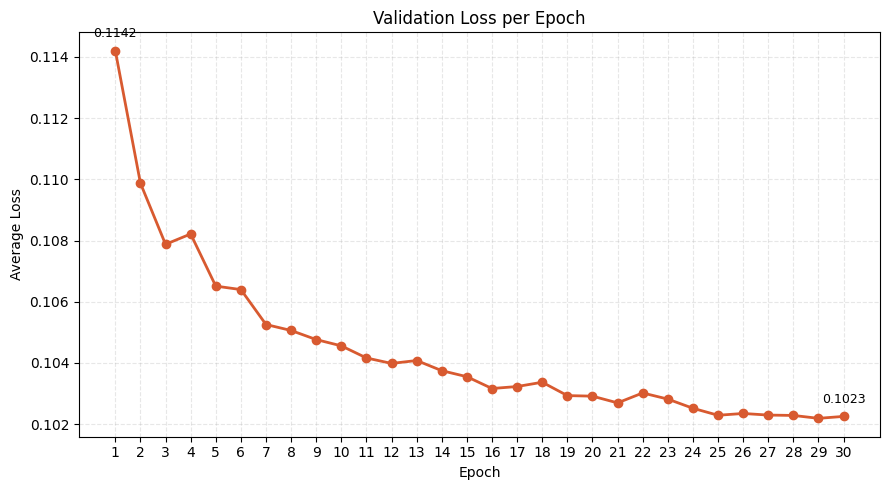

Saved to /content/drive/MyDrive/climate_twin_outputs/loss_curve.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch # Added this import to load the checkpoint
import os # Added this import to check file existence

def plot_loss_curve(epoch_losses, save_path='/content/drive/MyDrive/climate_twin_outputs/loss_curve.png'):
    """
    Args:
        epoch_losses: list of avg loss per epoch, e.g. [0.1354, 0.1095, 0.1069, ...]
    """
    epochs = list(range(1, len(epoch_losses) + 1))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(epochs, epoch_losses, marker='o', linewidth=2, markersize=6,
            color='#D85A30', markerfacecolor='#D85A30')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Average Loss') # Changed label for clarity
    ax.set_title('Validation Loss per Epoch') # Changed title to reflect validation loss
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(epochs)

    # Annotate first and last point with values
    ax.annotate(f'{epoch_losses[0]:.4f}', (epochs[0], epoch_losses[0]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    ax.annotate(f'{epoch_losses[-1]:.4f}', (epochs[-1], epoch_losses[-1]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

# --- Load history from checkpoint ---
CHECKPOINT_PATH = '/content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt'

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading history from {CHECKPOINT_PATH}...")
    # Load to CPU to avoid potential CUDA memory issues or device mismatches
    checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
    loaded_history = checkpoint['history']
    epoch_losses_for_plot = loaded_history['val_loss'] # Plotting validation loss

    if not epoch_losses_for_plot:
        print("No validation loss data found in the checkpoint history. Plotting training loss instead.")
        epoch_losses_for_plot = loaded_history.get('train_loss', [])
        if epoch_losses_for_plot:
            print("Using training loss for plotting.")
            plot_loss_curve(epoch_losses_for_plot, save_path='/content/drive/MyDrive/climate_twin_outputs/train_loss_curve.png')
        else:
            print("No training loss data found either. Cannot plot loss curve.")
    else:
        print(f"Loaded validation losses for {len(epoch_losses_for_plot)} epochs.")
        plot_loss_curve(epoch_losses_for_plot)
else:
    print(f"Checkpoint not found at {CHECKPOINT_PATH}. Cannot plot loss curve. Please ensure training has run and the checkpoint is saved to this path.")


In [10]:
import torch
import numpy as np
import zarr
import os
from torch.amp import autocast
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# CELL 4 — FINAL TEST EVALUATION
# Run this exactly ONCE, after all training/tuning is complete.
# This is your honest, untouched 2025 performance number.
# ==========================================

@torch.no_grad()
def evaluate_test_set(model, test_loader, device, clim_path='/content/drive/MyDrive/climate_twin_climatology.zarr'):
    """
    Runs the trained model once over the test set and computes:
      1. The same weighted L1 loss used during training (normalized space)
         — for direct comparison against train/val loss in history
      2. Per-variable MAE and RMSE in REAL-WORLD units (mm/day, °C)
         — this is the number that actually means something to a judge
    """
    model.eval()

    VARS = ['rainfall', 'max_temp', 'min_temp']

    # Load climatology to denormalize predictions back to real units
    # The clim_path is a directory containing 'mean' and 'std' Zarr groups.
    # We need to open these sub-groups directly.
    mean_group = zarr.open(os.path.join(clim_path, 'mean'), mode='r')
    std_group  = zarr.open(os.path.join(clim_path, 'std'), mode='r')

    mean_arr = np.stack([mean_group[v][:] for v in VARS], axis=0)  # (3, H, W)
    std_arr  = np.stack([std_group[v][:]  for v in VARS], axis=0)

    var_weights = torch.tensor([1.5, 1.0, 1.0]).view(1, 1, 3, 1, 1).to(device)

    total_weighted_loss = 0.0
    n_batches = 0

    # Accumulate squared/absolute errors per variable, in real-world units
    sum_abs_err = np.zeros(3)
    sum_sq_err  = np.zeros(3)
    n_samples   = 0

    with autocast(device_type='cuda', dtype=torch.float16):
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            pred = model(x_batch)

            # Same metric used during training, for direct comparability
            loss = (torch.abs(pred - y_batch) * var_weights).mean()
            total_weighted_loss += loss.item()
            n_batches += 1

            # ── Denormalize both pred and target to real-world units ──
            pred_np = pred.float().cpu().numpy()      # (B, 1, 3, H, W)
            true_np = y_batch.float().cpu().numpy()

            for arr in (pred_np, true_np):
                arr *= (std_arr[np.newaxis, np.newaxis] + 1e-6)
                arr += mean_arr[np.newaxis, np.newaxis]

            # Reverse log1p on rainfall channel only
            pred_np[:, :, 0] = np.clip(np.expm1(pred_np[:, :, 0]), 0, None)
            true_np[:, :, 0] = np.clip(np.expm1(true_np[:, :, 0]), 0, None)

            err = pred_np - true_np  # (B, 1, 3, H, W)
            sum_abs_err += np.abs(err).sum(axis=(0, 1, 3, 4))
            sum_sq_err  += (err ** 2).sum(axis=(0, 1, 3, 4))
            n_samples   += err.shape[0] * err.shape[1] * err.shape[3] * err.shape[4]

    avg_loss = total_weighted_loss / n_batches
    mae  = sum_abs_err / n_samples
    rmse = np.sqrt(sum_sq_err / n_samples)

    model.train()

    return {
        'normalized_loss': avg_loss,
        'mae':  {VARS[i]: mae[i]  for i in range(3)},
        'rmse': {VARS[i]: rmse[i] for i in range(3)},
    }


# ── Run once, after Cell 3 has finished and `model` holds final trained weights ──
# Ensure `test_loader` and `model` exist from previous cells
# (The assert below will be uncommented once model definition is in place or test is being run)
# assert 'test_loader' in globals(), \
#     "test_loader not found — did Cell 2 finish running in this kernel session?"
# assert 'model' in globals(), \
#     "model not found — did model architecture and instantiation cell finish running?"

# --- Load model weights here to make this cell self-contained for evaluation ---
model_checkpoint_path = '/content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt'

# --- Model definition for self-containment ---
# These are copied from the training cell (pn60ZJANajbg) to ensure self-contained execution
class WindowedSpatialAttention(nn.Module):
    def __init__(self, in_channels, window_size=8):
        super().__init__()
        self.window_size = window_size
        reduced = max(in_channels // 8, 1)
        self.query = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.proj  = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def _pad_to_window(self, x):
        _, _, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        return x, H, W

    def _partition(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        x = x.view(B, C, H // ws, ws, W // ws, ws)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        return x.view(-1, C, ws, ws)

    def _unpartition(self, x, B, H_pad, W_pad):
        ws = self.window_size
        C = x.shape[1]
        nH, nW = H_pad // ws, W_pad // ws
        x = x.view(B, nH, nW, C, ws, ws)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
        return x.view(B, C, H_pad, W_pad)

    def forward(self, x):
        B, C, H, W = x.shape
        x_pad, H_orig, W_orig = self._pad_to_window(x)
        _, _, H_pad, W_pad = x_pad.shape

        q = self._partition(self.query(x_pad))
        k = self._partition(self.key(x_pad))
        v = self._partition(self.value(x_pad))

        BW, C_qk, ws, _ = q.shape
        C_v = v.shape[1]
        ws2 = ws * ws

        q = q.view(BW, C_qk, ws2).permute(0, 2, 1)
        k = k.view(BW, C_qk, ws2)
        v = v.view(BW, C_v,  ws2)

        attn = torch.softmax(torch.bmm(q, k) * (C_qk ** -0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(BW, C_v, ws, ws)

        out = self._unpartition(out, B, H_pad, W_pad)
        out = self.proj(out[:, :, :H_orig, :W_orig])
        return x + self.gamma * out


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 4 * hidden_dim,
            kernel_size, padding=padding
        )

    def forward(self, x, cur_state):
        h_cur, c_cur = cur_state
        combined_conv = self.conv(torch.cat([x, h_cur], dim=1))
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(cc_f) * c_cur + torch.sigmoid(cc_i) * torch.tanh(cc_g)
        h_next = torch.sigmoid(cc_o) * torch.tanh(c_next)
        return h_next, c_next


class ClimateDigitalTwinModel(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, kernel_size=3, window_size=8):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv_in   = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.convlstm  = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        self.attention = WindowedSpatialAttention(hidden_dim, window_size=window_size)
        self.conv_out  = nn.Conv2d(hidden_dim, input_channels, kernel_size=3, padding=1)

    def forward(self, x):
        B, seq_len, C, H, W = x.size()
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(seq_len):
            x_t = self.conv_in(x[:, t])
            h, c = self.convlstm(x_t, (h, c))
            h = self.attention(h)
        return self.conv_out(h).unsqueeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ClimateDigitalTwinModel(
    input_channels=3, hidden_dim=64, kernel_size=3, window_size=8
).to(device)

# Load model weights
if os.path.exists(model_checkpoint_path):
    print(f"Loading model weights from {model_checkpoint_path}...")
    # Load to CPU to avoid potential CUDA memory issues, then move to device
    checkpoint = torch.load(model_checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state'])
    print("Model weights loaded successfully.")
else:
    raise FileNotFoundError(f"Model checkpoint not found at {model_checkpoint_path}")

# Sanity check the test_loader from Cell 2 actually exists
assert 'test_loader' in globals(), \
    "test_loader not found — did Cell 2 finish running in this kernel session?"

import json # Import json for saving results

test_results = evaluate_test_set(model, test_loader, device)

print("="*55)
print("TEST SET RESULTS — 2025, never seen during training or tuning")
print("="*55)
print(f"\nNormalized weighted loss: {test_results['normalized_loss']:.4f}")
print(f"  (compare to history['train_loss'][-1] and history['val_loss'][-1])")

print(f"\nReal-world metrics:")
print(f"{'Variable':<15}{'MAE':>12}{'RMSE':>12}")
for v in ['rainfall', 'max_temp', 'min_temp']:
    unit = 'mm/day' if v == 'rainfall' else '°C'
    print(f"{v:<15}{test_results['mae'][v]:>9.2f} {unit:<5}{test_results['rmse'][v]:>9.2f} {unit}")

# Save alongside your checkpoint for the writeup
# Ensure the directory exists before saving the file
output_dir = '/content/drive/MyDrive/climate_twin_outputs'
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"\nSaved to {os.path.join(output_dir, 'test_results.json')}")

Loading model weights from /content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt...
Model weights loaded successfully.


/tmp/ipykernel_35189/327702866.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda', dtype=torch.float16):


TEST SET RESULTS — 2025, never seen during training or tuning

Normalized weighted loss: 0.1072
  (compare to history['train_loss'][-1] and history['val_loss'][-1])

Real-world metrics:
Variable                MAE        RMSE
rainfall            0.89 mm/day     5.60 mm/day
max_temp            0.30 °C        0.84 °C
min_temp            0.21 °C        0.76 °C

Saved to /content/drive/MyDrive/climate_twin_outputs/test_results.json


In [18]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/climate_twin_model_weights.pth")

In [11]:
import torch
import numpy as np
import pandas as pd
from torch.amp import autocast
import zarr
import os # Import os for path joining

# ==========================================
# CORE QUERY FUNCTION
# This is the ONE function that does everything.
# Right now: called with a date string, prints a table.
# Later: called from Streamlit with a date picker, results go to a map.
# The function signature/logic never changes — only the caller does.
# ==========================================

VARS      = ['rainfall', 'max_temp', 'min_temp']
VAR_NAMES = ['Rainfall (mm/day)', 'Max Temp (°C)', 'Min Temp (°C)']

def get_weather_report(query_date, model, device,
                        zarr_path='/content/drive/MyDrive/climate_twin_cache.zarr',
                        clim_path='/content/drive/MyDrive/climate_twin_climatology.zarr',
                        region='All India'):
    """
    Core inference function — decoupled from any specific input/output format.

    Args:
        query_date: str 'YYYY-MM-DD' — the date to treat as "today"
                    Model uses the 4 days BEFORE this date as input,
                    predicts this date + next 6 days.
        model: trained ClimateDigitalTwinModel
        device: torch.device
        region: str — for future dashboard region filtering (no-op for now)

    Returns:
        dict with keys:
            'current':  dict of {var_name: spatial_mean_value} for query_date
            'forecast': pandas DataFrame, 7 rows (day 1-7) x 3 columns (vars)
            'raw_grids': numpy array (7, 3, 135, 129) — full spatial data,
                         kept for when the dashboard needs the map view
    """
    # ── Locate the date in the zarr time index ──
    zg = zarr.open(zarr_path, mode='r')
    n_days = zg['rainfall'].shape[0]
    start_date = pd.Timestamp('1980-01-01')
    target_date = pd.Timestamp(query_date)

    day_idx = (target_date - start_date).days

    if day_idx < 4:
        raise ValueError(f"Date too early — need 4 days of history before {query_date}")
    if day_idx >= n_days:
        raise ValueError(f"Date {query_date} is beyond available data (max: "
                          f"{(start_date + pd.Timedelta(days=n_days-1)).date()})")

    # ── Load climatology for denormalization ──
    # The clim_path is a directory containing 'mean' and 'std' Zarr groups.
    # We need to open these sub-groups directly.
    mean_group = zarr.open(os.path.join(clim_path, 'mean'), mode='r')
    std_group  = zarr.open(os.path.join(clim_path, 'std'), mode='r')

    mean_arr = np.stack([mean_group[v][:] for v in VARS], axis=0)
    std_arr  = np.stack([std_group[v][:]  for v in VARS], axis=0)

    # ── Load the 4-day input window ──
    chunks = [zg[v][day_idx-4:day_idx] for v in VARS]
    input_window = np.stack(chunks, axis=1).astype(np.float32)  # (4, 3, 135, 129)
    np.nan_to_num(input_window, copy=False, nan=0.0)

    input_tensor = torch.from_numpy(input_window).unsqueeze(0).to(device)  # (1,4,3,135,129)

    # ── Run 7-day autoregressive rollout ──
    model.eval()
    preds = []
    current_input = input_tensor.clone()

    with torch.no_grad():
        with autocast(device_type='cuda', dtype=torch.float16):
            for _ in range(7):
                pred = model(current_input)
                preds.append(pred.cpu())
                current_input = torch.cat([current_input[:, 1:], pred], dim=1)

    forecast_tensor = torch.cat(preds, dim=1)  # (1, 7, 3, 135, 129)

    # ── Post-process: denormalize + reverse log1p ──
    raw = forecast_tensor.squeeze(0).float().numpy()  # (7, 3, 135, 129)
    raw = raw * (std_arr[np.newaxis] + 1e-6) + mean_arr[np.newaxis]
    raw[:, 0] = np.expm1(raw[:, 0])              # rainfall: reverse log
    raw[:, 0] = np.clip(raw[:, 0], 0, None)       # rainfall can't be negative
    raw[:, 1] = np.clip(raw[:, 1], -5, 60)        # max_temp sanity bounds
    raw[:, 2] = np.clip(raw[:, 2], -10, 45)       # min_temp sanity bounds

    # ── "Current conditions" ── also denormalize the last input day ──
    current_norm = input_window[-1]               # (3, 135, 129)
    current_raw = current_norm * (std_arr + 1e-6) + mean_arr
    current_raw[0] = np.clip(np.expm1(current_raw[0]), 0, None)
    current_raw[1] = np.clip(current_raw[1], -5, 60)
    current_raw[2] = np.clip(current_raw[2], -10, 45)

    current_dict = {
        VAR_NAMES[i]: float(current_raw[i].mean()) for i in range(3)
    }

    # ── Build forecast table ──
    forecast_dates = [target_date + pd.Timedelta(days=d) for d in range(7)]
    table_data = {
        'Date': [d.strftime('%Y-%m-%d (%a)') for d in forecast_dates],
        'Rainfall (mm/day)': [round(raw[d, 0].mean(), 1) for d in range(7)],
        'Max Temp (°C)':     [round(raw[d, 1].mean(), 1) for d in range(7)],
        'Min Temp (°C)':     [round(raw[d, 2].mean(), 1) for d in range(7)],
    }
    forecast_df = pd.DataFrame(table_data)

    return {
        'current': current_dict,
        'forecast': forecast_df,
        'raw_grids': raw,         # kept for later map use, unused right now
        'query_date': query_date,
        'region': region,
    }


# ==========================================
# CURRENT INTERFACE: simple function call, print as table
# (this is what you swap out later for a Streamlit input/output)
# ==========================================
def print_weather_report(query_date, model, device):
    result = get_weather_report(query_date, model, device)

    print(f"\n{'='*60}")
    print(f"Weather Report — query date: {result['query_date']}")
    print(f"{'='*60}")

    print(f"\nCurrent conditions (day before query date):")
    for k, v in result['current'].items():
        print(f"  {k:25s}: {v:.1f}")

    print(f"\n7-Day Forecast:")
    print(result['forecast'].to_string(index=False))
    print(f"\n{'='*60}\n")

    return result


# ── USAGE ──
# Ensure `model` and `device` exist from previous cells before running
# assert 'model' in globals(), "Model not found. Please run the model definition cell first."
# assert 'device' in globals(), "Device not found. Please run the model definition cell first."

result = print_weather_report('2015-07-15', model, device)

# The DataFrame is also available directly for any further use:
# result['forecast']  → pandas DataFrame, ready to .to_csv(), display(), etc.

/tmp/ipykernel_35189/2512203776.py:77: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda', dtype=torch.float16):



Weather Report — query date: 2015-07-15

Current conditions (day before query date):
  Rainfall (mm/day)        : 3.0
  Max Temp (°C)            : 40.5
  Min Temp (°C)            : 30.6

7-Day Forecast:
            Date  Rainfall (mm/day)  Max Temp (°C)  Min Temp (°C)
2015-07-15 (Wed)                1.2           40.5           30.6
2015-07-16 (Thu)                0.7           40.6           30.6
2015-07-17 (Fri)                0.6           40.6           30.6
2015-07-18 (Sat)                0.6           40.6           30.6
2015-07-19 (Sun)                0.5           40.6           30.6
2015-07-20 (Mon)                0.5           40.6           30.6
2015-07-21 (Tue)                0.5           40.6           30.6




Generating model forecast for query date: 2015-07-15


/tmp/ipykernel_35189/2512203776.py:77: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda', dtype=torch.float16):


Retrieving ground truth for forecast period...


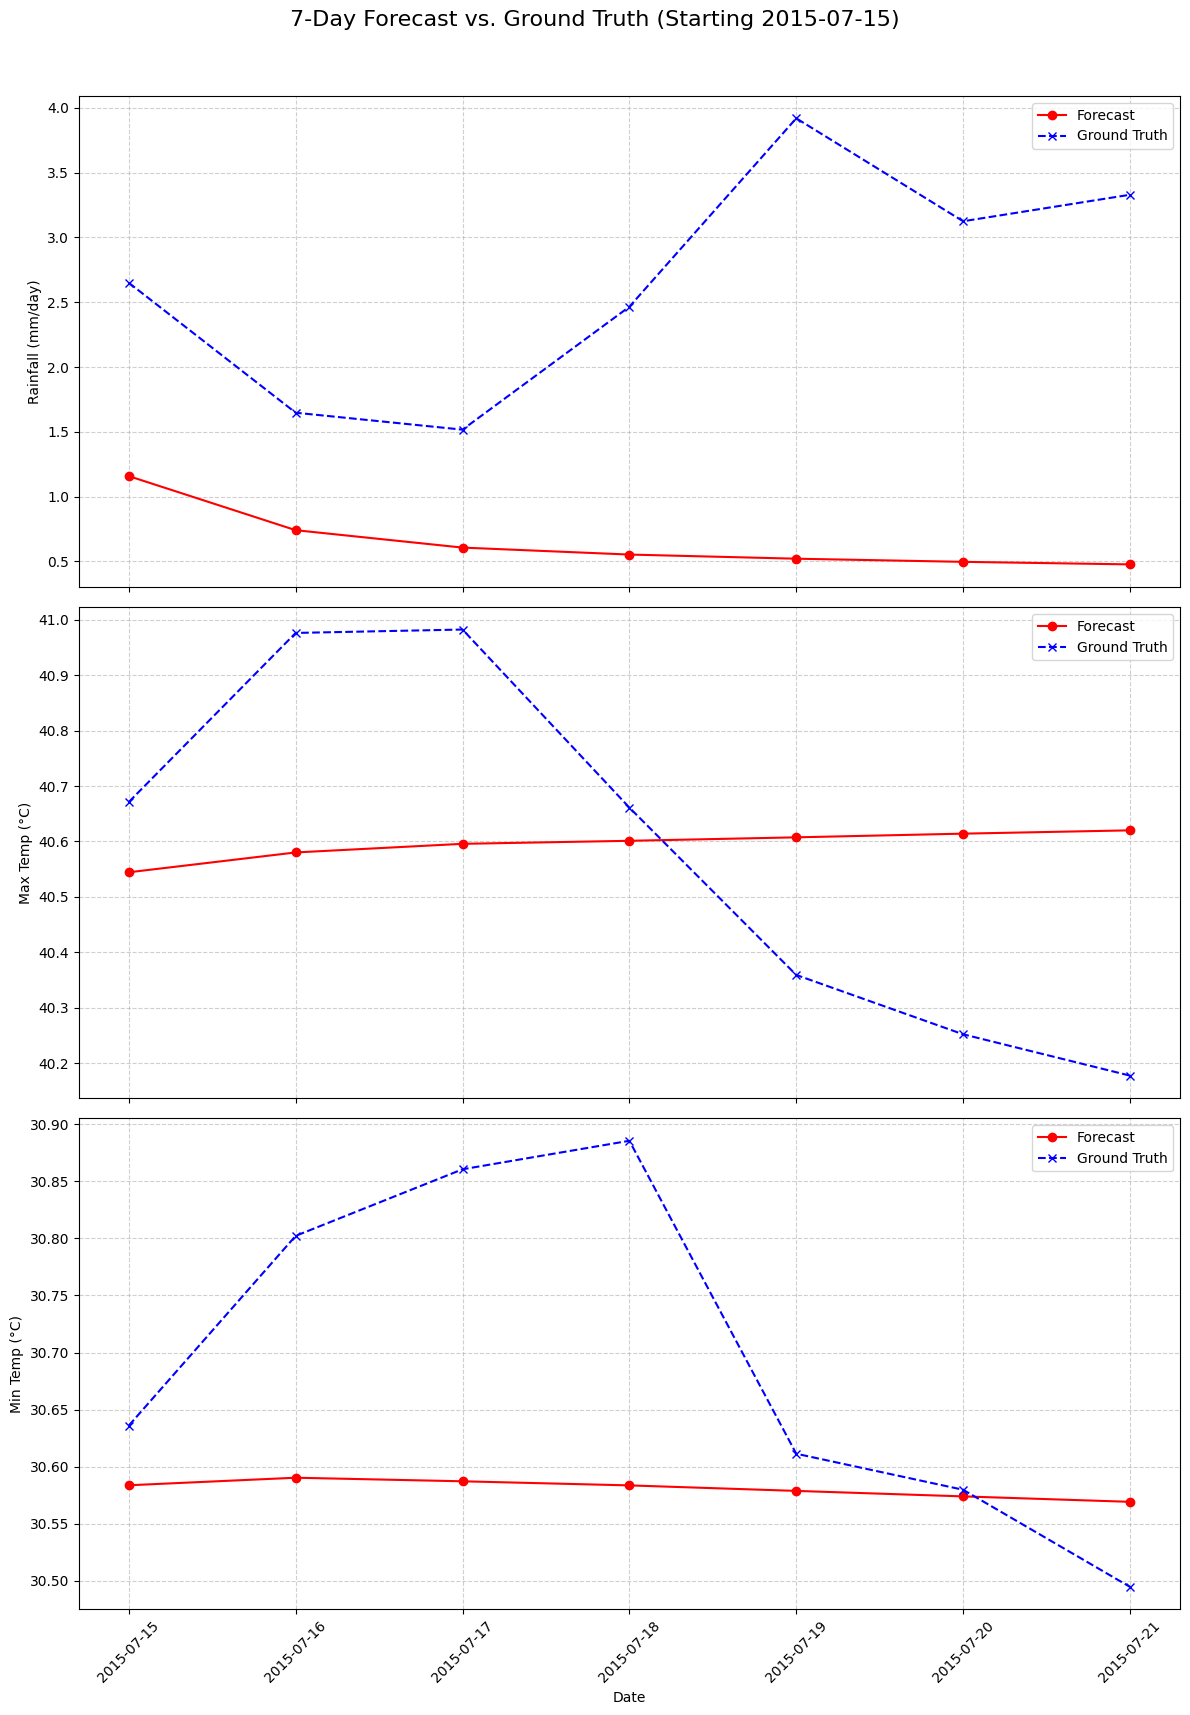


--- Quantitative Comparison (7-Day Forecast MAE/RMSE) ---
Rainfall (mm/day)   : MAE = 2.45 mm/day, RMSE = 10.26 mm/day
Max Temp (°C)       : MAE = 0.52 °C, RMSE = 1.19 °C
Min Temp (°C)       : MAE = 0.24 °C, RMSE = 0.73 °C
Comparison plot saved to /content/drive/MyDrive/climate_twin_outputs/forecast_vs_ground_truth_2015-07-15.png


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import numpy as np
import os # For os.path.join

# Define the query date for comparison. This will be the start of the 7-day forecast.
query_date_comparison = '2015-07-15'

# 1. Get the model's forecast
print(f"Generating model forecast for query date: {query_date_comparison}")
forecast_result = get_weather_report(query_date_comparison, model, device,
                                      zarr_path=LOCAL_ZARR_PATH,
                                      clim_path=CLIMATOLOGY_ZARR_PATH)
forecast_raw_grids = forecast_result['raw_grids'] # (7, 3, 135, 129)

# 2. Get the historical ground truth for the 7-day forecast period
print(f"Retrieving ground truth for forecast period...")

# Open the main Zarr store
zg = zarr.open(LOCAL_ZARR_PATH, mode='r')

# This is the hardcoded start date in ClimateDigitalTwinDataset and ut9qljnkbAno
start_date_zarr = pd.Timestamp('1980-01-01')
target_date_forecast_start = pd.Timestamp(query_date_comparison)

# Calculate the start index in the Zarr store for the 7-day forecast period
day_idx_forecast_start = (target_date_forecast_start - start_date_zarr).days

# Load the 7-day ground truth normalized data
chunks_gt_norm = [zg[v][day_idx_forecast_start : day_idx_forecast_start + 7] for v in VARS]
ground_truth_norm_data = np.stack(chunks_gt_norm, axis=1).astype(np.float32)  # (7, 3, H, W)
np.nan_to_num(ground_truth_norm_data, copy=False, nan=0.0)

# Load climatology for denormalization
mean_group = zarr.open(os.path.join(CLIMATOLOGY_ZARR_PATH, 'mean'), mode='r')
std_group  = zarr.open(os.path.join(CLIMATOLOGY_ZARR_PATH, 'std'), mode='r')

mean_arr = np.stack([mean_group[v][:] for v in VARS], axis=0) # (3, H, W)
std_arr  = np.stack([std_group[v][:]  for v in VARS], axis=0) # (3, H, W)

# Denormalize ground truth
ground_truth_raw_grids = ground_truth_norm_data * (std_arr[np.newaxis] + 1e-6) + mean_arr[np.newaxis] # (7, 3, H, W)

# Apply inverse log1p and clipping for rainfall
ground_truth_raw_grids[:, 0] = np.expm1(ground_truth_raw_grids[:, 0])
ground_truth_raw_grids[:, 0] = np.clip(ground_truth_raw_grids[:, 0], 0, None)
ground_truth_raw_grids[:, 1] = np.clip(ground_truth_raw_grids[:, 1], -5, 60)
ground_truth_raw_grids[:, 2] = np.clip(ground_truth_raw_grids[:, 2], -10, 45)

# 3. Calculate Daily Mean values for comparison (averaged over spatial dimensions)
forecast_daily_means = forecast_raw_grids.mean(axis=(2, 3)) # Shape (7, 3)
ground_truth_daily_means = ground_truth_raw_grids.mean(axis=(2, 3)) # Shape (7, 3)

forecast_dates_for_plot = [target_date_forecast_start + pd.Timedelta(days=d) for d in range(7)]

# 4. Visualize comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle(f'7-Day Forecast vs. Ground Truth (Starting {query_date_comparison})', fontsize=16)

for i, var_name in enumerate(VAR_NAMES):
    ax = axes[i]
    ax.plot(forecast_dates_for_plot, forecast_daily_means[:, i], label='Forecast', marker='o', linestyle='-', color='red')
    ax.plot(forecast_dates_for_plot, ground_truth_daily_means[:, i], label='Ground Truth', marker='x', linestyle='--', color='blue')
    ax.set_ylabel(var_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# 5. Calculate and display MAE/RMSE for the 7-day period (averaged over spatial dimensions and time)
print("\n--- Quantitative Comparison (7-Day Forecast MAE/RMSE) ---")
comparison_metrics = {}
for i, var_name in enumerate(VAR_NAMES):
    forecast_var = forecast_raw_grids[:, i] # (7, 135, 129)
    ground_truth_var = ground_truth_raw_grids[:, i] # (7, 135, 129)

    # Calculate MAE across all spatial points and forecast days for this variable
    mae = np.mean(np.abs(forecast_var - ground_truth_var))
    # Calculate RMSE across all spatial points and forecast days for this variable
    rmse = np.sqrt(np.mean((forecast_var - ground_truth_var)**2))

    unit = 'mm/day' if VARS[i] == 'rainfall' else '°C'
    print(f"{var_name:<20}: MAE = {mae:.2f} {unit}, RMSE = {rmse:.2f} {unit}")
    comparison_metrics[var_name] = {'mae': mae, 'rmse': rmse}

# Optional: Save the plot
output_dir = '/content/drive/MyDrive/climate_twin_outputs'
os.makedirs(output_dir, exist_ok=True)
plot_save_path = os.path.join(output_dir, f'forecast_vs_ground_truth_{query_date_comparison}.png')
fig.savefig(plot_save_path, dpi=150, bbox_inches='tight')
print(f"Comparison plot saved to {plot_save_path}")